# Simulasi Dinamika Sistem Penyangga (Buffer) Darah Manusia
Pemodelan ketahanan *buffer* bikarbonat ($HCO_3^-$) terhadap infusi asam laktat konstan menggunakan integrasi numerik Persamaan Diferensial Biasa (ODE).

---

In [6]:
# Import library
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

### 1. Inisialisasi Parameter Biologis & Kondisi Awal
Bagian ini mendefinisikan nilai awal cairan fisiologis darah pada ekuilibrium (pH 7.4). Konstanta laju reaksi dihitung berdasarkan konstanta kesetimbangan asam ($pK_a$) bikarbonat pada suhu tubuh.

In [7]:
# Kondisi normal darah manusia
pH_awal = 7.4
H_awal = 10**(-pH_awal)      # konsentrasi ion H+ awal (Molar)
HCO3_awal = 0.024            # konsentrasi Bikarbonat normal ~24 mM (Molar)
H2CO3_awal = 0.0012          # konsentrasi Asam Karbonat normal ~1.2 mM (Molar)

# Reaksi: H2CO3 <--> H+ + HCO3-
Ka = (H_awal * HCO3_awal) / H2CO3_awal
kr = 1.0e5                   # laju asosiasi
kf = Ka * kr                 # laju disosiasi

# variabel infusi asam laktat
v_asam = 2.5e-7 

y0 = [H_awal, HCO3_awal, H2CO3_awal]

print("Parameter awal berhasil diinisialisasi.")

Parameter awal berhasil diinisialisasi.


### 2. Definisi Sistem Persamaan Diferensial Biasa (ODE)
Sistem ini menggunakan Hukum Aksi Massa untuk memodelkan laju perubahan molaritas ketiga komponen secara simultan. Persamaan matematisnya adalah sebagai berikut:
1. $\frac{d[H^+]}{dt} = k_f[H_2CO_3] - k_r[H^+][HCO_3^-] + v_{asam}$
2. $\frac{d[HCO_3^-]}{dt} = k_f[H_2CO_3] - k_r[H^+][HCO_3^-]$
3. $\frac{d[H_2CO_3]}{dt} = -k_f[H_2CO_3] + k_r[H^+][HCO_3^-]$

In [8]:
def kinetika_buffer(y, t, kf, kr, v_asam):
    """Fungsi yang mengembalikan turunan (laju perubahan) dari sistem penyangga."""
    H, HCO3, H2CO3 = y
    
    laju_disosiasi = kf * H2CO3
    laju_asosiasi = kr * H * HCO3
    
    # sistem persamaan diferensial
    dH_dt = laju_disosiasi - laju_asosiasi + v_asam
    dHCO3_dt = laju_disosiasi - laju_asosiasi
    dH2CO3_dt = -laju_disosiasi + laju_asosiasi
    
    return [dH_dt, dHCO3_dt, dH2CO3_dt]


t = np.linspace(0, 1200, 2000)

# gunakan odeint untuk menyelesaikan sistem persamaan diferensial
solusi = odeint(kinetika_buffer, y0, t, args=(kf, kr, v_asam))

H_hasil = solusi[:, 0]
HCO3_hasil = solusi[:, 1] * 1000
H2CO3_hasil = solusi[:, 2] * 1000 
pH_hasil = -np.log10(H_hasil)

print("Komputasi integrasi diferensial selesai.")

Komputasi integrasi diferensial selesai.


### 4. Visualisasi Trajektori dan Pencarian Titik Gagal (*Tipping Point*)
Visualisasi matriks hasil dan evaluasi array untuk mendeteksi kapan sistem pertahanan kimiawi tertembus.

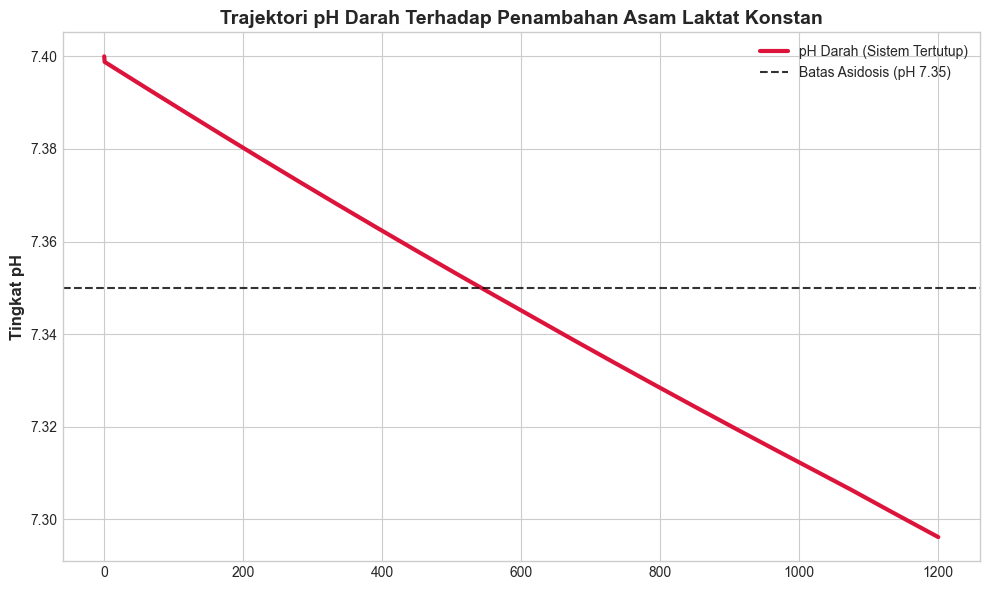

[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-542.7


<Figure size 640x480 with 0 Axes>

In [9]:

fig, ax1 = plt.subplots(figsize=(10, 6))

# trajektori pH darah terhadap penambahan asam laktat konstan
ax1.plot(t, pH_hasil, color='crimson', linewidth=3, label='pH Darah (Sistem Tertutup)')
ax1.axhline(y=7.35, color='black', linestyle='--', alpha=0.8, label='Batas Asidosis (pH 7.35)')

ax1.set_ylabel('Tingkat pH', fontsize=12, fontweight='bold')
ax1.set_title('Trajektori pH Darah Terhadap Penambahan Asam Laktat Konstan', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()
plt.savefig('assets/trajektori-pH-darah.png', dpi=300)

idx_asidosis = np.argmax(pH_hasil < 7.35)
waktu_asidosis = t[idx_asidosis]

if idx_asidosis > 0:
    print(f"[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-{waktu_asidosis:.1f}")
else:
    print("[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.")

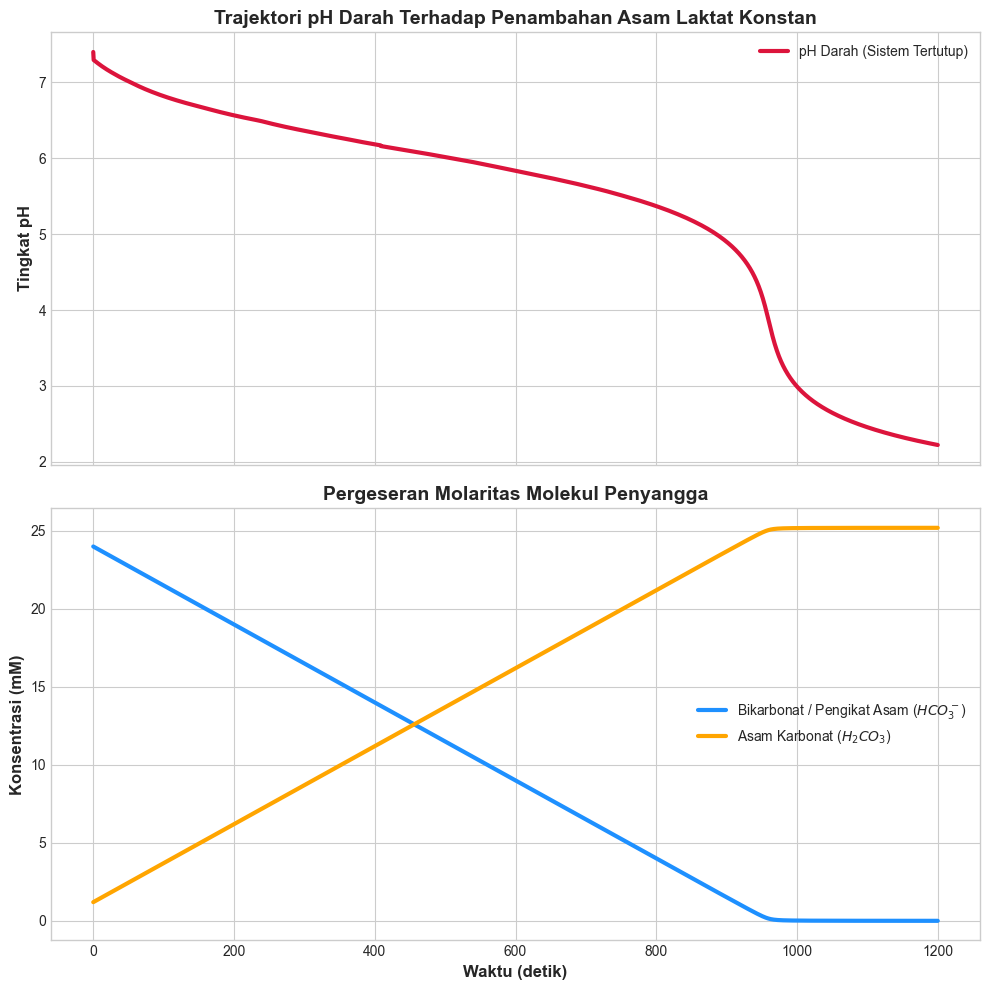

[!] Kegagalan Sistem: Molekul penyangga bikarbonat jenuh pada detik ke-941.9


<Figure size 640x480 with 0 Axes>

In [15]:
v_asam_hiperbola = 2.5e-5
solusi_hiperbola = odeint(kinetika_buffer, y0, t, args=(kf, kr, v_asam_hiperbola))

H_hiperbola = solusi_hiperbola[:, 0]
HCO3_hiperbola = solusi_hiperbola[:, 1] * 1000
H2CO3_hiperbola = solusi_hiperbola[:, 2] * 1000
pH_hiperbola = -np.log10(H_hiperbola)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# trajektori pH darah terhadap konsentrasi buffer
ax1.plot(t, pH_hiperbola, color='crimson', linewidth=3, label='pH Darah (Sistem Tertutup)')
ax1.set_ylabel('Tingkat pH', fontsize=12, fontweight='bold')
ax1.set_title('Trajektori pH Darah Terhadap Penambahan Asam Laktat Konstan', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')

ax2.plot(t, HCO3_hiperbola, color='dodgerblue', linewidth=3, label='Bikarbonat / Pengikat Asam ($HCO_3^-$)')
ax2.plot(t, H2CO3_hiperbola, color='orange', linewidth=3, label='Asam Karbonat ($H_2CO_3$)')
ax2.set_xlabel('Waktu (detik)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Konsentrasi (mM)', fontsize=12, fontweight='bold')
ax2.set_title('Pergeseran Molaritas Molekul Penyangga', fontsize=14, fontweight='bold')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()
plt.savefig('assets/konsentrasi-buffer.png', dpi=300)

idx_habis = np.argmax(HCO3_hiperbola < 0.5)
waktu_habis = t[idx_habis]
    
if idx_habis > 0:
    print(f"[!] Kegagalan Sistem: Molekul penyangga bikarbonat jenuh pada detik ke-{waktu_habis:.1f}")
else:
    print("[-] Molekul penyangga masih tersedia hingga akhir simulasi.")

In [11]:
def kinetika_buffer_intervensi(y, t, kf, kr, v_asam):
    """Fungsi ODE Skenario B: Terdapat injeksi buffer HCO3- di tengah krisis."""
    H, HCO3, H2CO3 = y
    
    laju_disosiasi = kf * H2CO3
    laju_asosiasi = kr * H * HCO3

    # logika intervensi pada 100 < t < 120
    v_injeksi = 0
    if 100 <= t <= 120:
        v_injeksi = 0.0001145
    
    dH_dt = laju_disosiasi - laju_asosiasi + v_asam
    # v_injeksi ditambahkan khusus ke persediaan HCO3-
    dHCO3_dt = laju_disosiasi - laju_asosiasi + v_injeksi 
    dH2CO3_dt = -laju_disosiasi + laju_asosiasi
    
    return [dH_dt, dHCO3_dt, dH2CO3_dt]

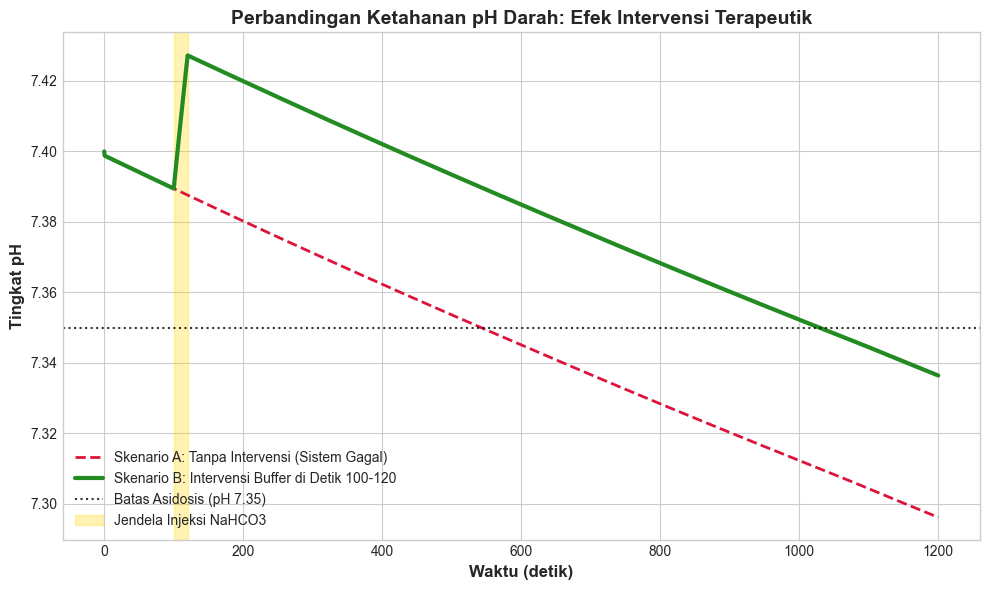

[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-1029.5


<Figure size 640x480 with 0 Axes>

In [16]:
v_asam = 2.5e-7
solusi_intervensi = odeint(kinetika_buffer_intervensi, y0, t, args=(kf, kr, v_asam))

H_hasil_B = solusi_intervensi[:, 0]
HCO3_hasil_B = solusi_intervensi[:, 1] * 1000  # Konversi ke mM
pH_hasil_B = -np.log10(H_hasil_B)

plt.figure(figsize=(10, 6))

plt.plot(t, pH_hasil, color='crimson', linewidth=2, linestyle='--', 
         label='Skenario A: Tanpa Intervensi (Sistem Gagal)')
plt.plot(t, pH_hasil_B, color='forestgreen', linewidth=3, 
         label='Skenario B: Intervensi Buffer di Detik 100-120')
plt.axhline(y=7.35, color='black', linestyle=':', alpha=0.8, label='Batas Asidosis (pH 7.35)')

# area intervensi
plt.axvspan(100, 120, color='gold', alpha=0.3, label='Jendela Injeksi NaHCO3')

plt.title('Perbandingan Ketahanan pH Darah: Efek Intervensi Terapeutik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu (detik)', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat pH', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
plt.savefig('assets/simulasi-intervensi.png', dpi=300)

idx_asidosis_B = np.argmax(pH_hasil_B < 7.35)
waktu_asidosis_B = t[idx_asidosis_B]

if idx_asidosis_B > 0:
    print(f"[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-{waktu_asidosis_B:.1f}")
else:
    print("[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.")

## kenapa angka intervensi injeksi harus spesifik? (ganti kuantitas atau ganti waktu bikin grafiknya ga tepat)

Ketika Anda menyuntikkan tambahan basa ($HCO_3^-$) dengan laju 0.0001, ion basa tersebut akan langsung berikatan dengan ion asam ($H^+$) di dalam darah.
1. Proses Kimia: Konsentrasi asam ($H^+$) berkurang secara perlahan.
2. Hasil Visual: Karena $H^+$ berkurang, tingkat keasaman menurun, yang berarti pH naik. Inilah mengapa pada rentang waktu detik ke-100 hingga 120, garis hijau melonjak naik ke atas membentuk "puncak" penyelamatan sebelum akhirnya turun kembali. Algoritma odeint Python berhasil menghitung pergeseran ini dengan mulus.

Ketika Anda melipatgandakan dosis menjadi 0.0002, Anda memasukkan basa dalam jumlah raksasa secara tiba-tiba ke dalam persamaan diferensial.
1. Ledakan Matematika: Perhatikan kembali persamaan laju asosiasi Anda:
$$laju\_asosiasi = k_r[H^+][HCO_3^-]$$
2. Karena konstanta laju ikatannya sangat besar ($k_r = 10^5$), lonjakan dadakan dari $HCO_3^-$ membuat komputer menginstruksikan sistem untuk "memusnahkan" $H^+$ dengan kecepatan ekstrem dalam sepersekian milidetik.
3. Menembus Nol (Angka Negatif): Di dunia nyata, jika $H^+$ habis, reaksinya berhenti (konsentrasi 0). Namun di dalam matematika murni, pengurangannya begitu agresif hingga konsentrasi $H^+$ bablas melewati nol dan menjadi angka negatif.

Ini adalah murni artifact (efek samping) dari cara Jupyter Notebook/Python bekerja:  
1. Ketika $H^+$ menjadi negatif, program mencoba menghitung nilai pH: pH = -np.log10(angka_negatif).
2. Matematika tidak mengizinkan logaritma dari angka negatif. Pustaka NumPy akan langsung memicu error (biasanya berupa RuntimeWarning: invalid value encountered in log10).
3. Karena kalkulasi di baris tersebut gagal, variabel array pH_hasil_B untuk skenario tersebut tidak berhasil diperbarui di memori komputer Anda.
4. Akibatnya, saat Anda menjalankan sel pembuatan grafik (plt.plot), notebook hanya mencetak ulang sisa memori data dari run sebelumnya yang belum terhapus (kemungkinan besar memori saat $v_{injeksi}$ masih bernilai 0). Itulah mengapa garis hijau tiba-tiba kehilangan "puncak"-nya dan bergerak persis menyerupai skenario tanpa intervensi.

In [13]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import differential_evolution

def kinetika_buffer_intervensi_param(y, t, kf, kr, v_asam, t0, durasi, v_injeksi):
    """
    ODE dengan intervensi injeksi HCO3- berbentuk pulse:
    aktif dari t0 sampai t0+durasi dengan laju v_injeksi (M/s).
    """
    H, HCO3, H2CO3 = y

    laju_disosiasi = kf * H2CO3
    laju_asosiasi = kr * H * HCO3

    inj = v_injeksi if (t0 <= t <= t0 + durasi) else 0.0

    dH_dt = laju_disosiasi - laju_asosiasi + v_asam
    dHCO3_dt = laju_disosiasi - laju_asosiasi + inj
    dH2CO3_dt = -laju_disosiasi + laju_asosiasi

    return [dH_dt, dHCO3_dt, dH2CO3_dt]

def simulasi_intervensi(params, y0, t, kf, kr, v_asam):
    """
    params = [t0, durasi, v_injeksi]
    """
    t0, durasi, v_injeksi = params

    sol = odeint(
        kinetika_buffer_intervensi_param,
        y0, t,
        args=(kf, kr, v_asam, t0, durasi, v_injeksi)
    )

    H = sol[:, 0]
    HCO3 = sol[:, 1]

    # pH aman dari log(<=0): clip agar tidak crash saat optimisasi
    pH = -np.log10(np.clip(H, 1e-14, None))

    return H, HCO3, pH

def objective_injeksi(params, y0, t, kf, kr, v_asam,
                     pH_target=7.35, w_drop=2000.0, w_time=20.0, w_dose=1.0):
    """
    Fungsi objektif yang diminimasi:
    - penalti jika pH minimum di bawah target
    - penalti durasi waktu pH di bawah target
    - penalti dosis total injeksi
    - penalti besar untuk solusi tak-fisik (H <= 0 / NaN)
    """
    t0, durasi, v_injeksi = params
    H, HCO3, pH = simulasi_intervensi(params, y0, t, kf, kr, v_asam)

    # Penalti solusi numerik tidak valid
    if np.any(~np.isfinite(H)) or np.any(~np.isfinite(pH)):
        return 1e12
    if np.min(H) <= 0 or np.min(HCO3) < 0:
        return 1e11 + 1e8 * abs(np.min(H))

    min_pH = np.min(pH)
    dt = t[1] - t[0]
    waktu_di_bawah_target = np.sum(pH < pH_target) * dt

    dosis_total = v_injeksi * durasi  # M (kira-kira area pulse)

    penalty_drop = max(0.0, pH_target - min_pH) ** 2
    penalty_time = waktu_di_bawah_target

    J = (
        w_drop * penalty_drop +
        w_time * penalty_time +
        w_dose * dosis_total
    )
    return J

def cari_injeksi_optimal(y0, t, kf, kr, v_asam):
    """
    Cari t0, durasi, dan v_injeksi optimal dengan global optimization.
    """
    t_start = float(t[0])
    t_end = float(t[-1])

    # bounds: (t0, durasi, v_injeksi)
    bounds = [
        (t_start, t_end - 10.0),  # t0
        (5.0, 120.0),             # durasi (detik)
        (1e-7, 5e-4)              # laju injeksi (M/s)
    ]

    result = differential_evolution(
        objective_injeksi,
        bounds=bounds,
        args=(y0, t, kf, kr, v_asam),
        seed=42,
        maxiter=80,
        popsize=20,
        tol=1e-3
    )

    best_t0, best_durasi, best_v = result.x
    H_opt, HCO3_opt, pH_opt = simulasi_intervensi(result.x, y0, t, kf, kr, v_asam)

    return {
        "t0_opt": best_t0,
        "durasi_opt": best_durasi,
        "v_injeksi_opt": best_v,
        "score_opt": result.fun,
        "pH_min_opt": float(np.min(pH_opt)),
        "success": bool(result.success),
        "message": result.message,
        "H_opt": H_opt,
        "HCO3_opt": HCO3_opt,
        "pH_opt": pH_opt
    }

In [14]:
hasil_opt = cari_injeksi_optimal(y0, t, kf, kr, v_asam)

print("t0 optimal     :", hasil_opt["t0_opt"])
print("durasi optimal :", hasil_opt["durasi_opt"])
print("v injeksi opt  :", hasil_opt["v_injeksi_opt"])
print("pH minimum     :", hasil_opt["pH_min_opt"])
print("score          :", hasil_opt["score_opt"])
print("success        :", hasil_opt["success"], "-", hasil_opt["message"])

C:\Users\Max\AppData\Local\Temp\ipykernel_19836\654564252.py:29: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(


t0 optimal     : 97.52481028821376
durasi optimal : 31.71995287663655
v injeksi opt  : 9.761916282090521e-05
pH minimum     : 7.350012859898536
score          : 0.0030964752445358243
success        : False - Maximum number of iterations has been exceeded.
